In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import os
import math

In [89]:
DATA_PATH = '../results'
TIME=['second', 'hour', 'day', 'week', 'year']
TITLE_MAP = {
    'second': '1 Second',
    'hour': '1 Hour',
    'day': '1 Day',
    'week': '1 Week',
    'year': '1 Year',
}
OUTPUT_DIR = 'graph/device'


In [93]:
def find_noise_threshold(df):

    mask = df['norm_accuracy'] >= 0.9895
    filtered_df = df[mask]

    result_df = (
        filtered_df
        .groupby(['device', 't_inference'])['noise_scale']
        .max()
        .reset_index()
        .rename(columns={'noise_scale': 'noise_tolerance'})
    )
    time_mapping = {
        1: 'second',
        3600: 'hour',
        3600 * 24: 'day',
        3600 * 24 * 7: 'week',
        3600 * 24 * 365: 'year'
    }

    result_df['time_str'] = result_df['t_inference'].map(time_mapping)
    return result_df

In [94]:

all_results = []
for time in TIME:
    csv_path = os.path.join(DATA_PATH, f'device_results_{time}.csv')
    df = pd.read_csv(csv_path)
    
    result_df = find_noise_threshold(df)
    all_results.append(result_df)

final_df = pd.concat(all_results, ignore_index=True)
'''mask_day = (final_df['device'] == 'liner_1') & (final_df['time_str'] == 'day')
mask_hour = (final_df['device'] == 'liner_1') & (final_df['time_str'] == 'hour')

val_day = final_df.loc[mask_day, 'noise_tolerance'].values[0]
val_hour = final_df.loc[mask_hour, 'noise_tolerance'].values[0]

final_df.loc[mask_day, 'noise_tolerance'] = val_hour
final_df.loc[mask_hour, 'noise_tolerance'] = val_day

# === liner_2: 交换 1 week 和 1 hour 的 noise_tolerance ===
mask_week = (final_df['device'] == 'liner_2') & (final_df['time_str'] == 'week')
mask_hour2 = (final_df['device'] == 'liner_2') & (final_df['time_str'] == 'hour')

val_week = final_df.loc[mask_week, 'noise_tolerance'].values[0]
val_hour2 = final_df.loc[mask_hour2, 'noise_tolerance'].values[0]

final_df.loc[mask_week, 'noise_tolerance'] = val_hour2
final_df.loc[mask_hour2, 'noise_tolerance'] = val_week
final_df.loc[(final_df['device'] == 'liner_2') & (final_df['time_str'] == 'year'), 'noise_tolerance'] = 2.00'''

"mask_day = (final_df['device'] == 'liner_1') & (final_df['time_str'] == 'day')\nmask_hour = (final_df['device'] == 'liner_1') & (final_df['time_str'] == 'hour')\n\nval_day = final_df.loc[mask_day, 'noise_tolerance'].values[0]\nval_hour = final_df.loc[mask_hour, 'noise_tolerance'].values[0]\n\nfinal_df.loc[mask_day, 'noise_tolerance'] = val_hour\nfinal_df.loc[mask_hour, 'noise_tolerance'] = val_day\n\n# === liner_2: 交换 1 week 和 1 hour 的 noise_tolerance ===\nmask_week = (final_df['device'] == 'liner_2') & (final_df['time_str'] == 'week')\nmask_hour2 = (final_df['device'] == 'liner_2') & (final_df['time_str'] == 'hour')\n\nval_week = final_df.loc[mask_week, 'noise_tolerance'].values[0]\nval_hour2 = final_df.loc[mask_hour2, 'noise_tolerance'].values[0]\n\nfinal_df.loc[mask_week, 'noise_tolerance'] = val_hour2\nfinal_df.loc[mask_hour2, 'noise_tolerance'] = val_week\nfinal_df.loc[(final_df['device'] == 'liner_2') & (final_df['time_str'] == 'year'), 'noise_tolerance'] = 2.00"

/tmp/ipykernel_77958/261155452.py:18: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = heatmap_data.applymap(lambda v: f"$\\sim${v:.2f}")


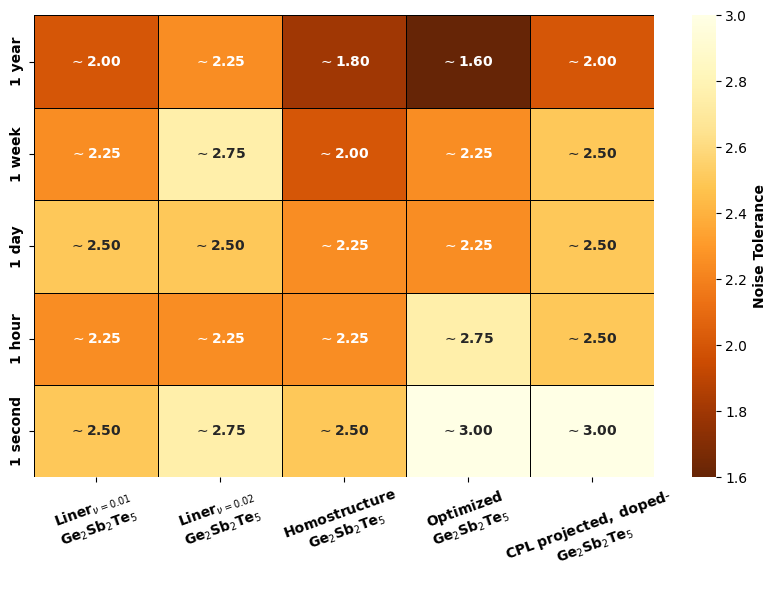

In [95]:

device_label_map = {
    'liner_1': "$\\mathbf{Liner}_{\\nu=0.01}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$",
    'liner_2': "$\\mathbf{Liner}_{\\nu=0.02}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$",
    'homo':     "$\\mathbf{Homostructure}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$",
    'opt':      "$\\mathbf{Optimized}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$",
    'cpl':      "$\\mathbf{CPL\\ projected,\\ doped\\text{-}}$\n$\\mathbf{Ge}_{2}\\mathbf{Sb}_{2}\\mathbf{Te}_{5}$"
}



final_df['device_pretty'] = final_df['device'].map(device_label_map)
final_df['time_label'] = final_df['time_str'].apply(lambda s: f'1 {s}')
heatmap_data = final_df.pivot(index='time_label', columns='device_pretty', values='noise_tolerance')
time_order = ['1 second', '1 hour', '1 day', '1 week', '1 year']
heatmap_data = heatmap_data.reindex(time_order)
device_order = [device_label_map[d] for d in ['liner_1', 'liner_2', 'homo', 'opt', 'cpl']]
heatmap_data = heatmap_data[device_order]
annot_data = heatmap_data.applymap(lambda v: f"$\\sim${v:.2f}")

plt.figure(figsize=(10, 6))
ax = sns.heatmap(
    data=heatmap_data,        
    annot=annot_data,        
    fmt="",                  
    cmap="YlOrBr_r",
    cbar_kws={'label': 'Noise Tolerance'},
    linewidths=0.6,
    linecolor='black'
)
ax.invert_yaxis()
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, weight='bold')
ax.collections[0].colorbar.ax.yaxis.label.set_size(10)
ax.collections[0].colorbar.ax.yaxis.label.set_weight('bold')
for text in ax.texts:
        text.set_fontsize(10)
        text.set_weight('bold')
plt.xticks(rotation=20)
os.makedirs(OUTPUT_DIR, exist_ok=True) 
#plt.savefig(f'{OUTPUT_DIR}/device_noise_tolerance.png')
plt.show()